In [ ]:
import os
import io
import re
import json
import uuid
import base64
import shutil
import requests
from tqdm import tqdm
from PIL import Image
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from unstructured.partition.pdf import partition_pdf
from langchain_core.documents import Document
from langchain_text_splitters import CharacterTextSplitter
from langchain.storage import InMemoryStore
from langchain_chroma import Chroma
from langchain.chains.llm import LLMChain, PromptTemplate
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.prompts.chat import ChatPromptTemplate, HumanMessagePromptTemplate, SystemMessagePromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain.retrievers.multi_vector import MultiVectorRetriever
from langchain_groq import ChatGroq
from langchain.embeddings import HuggingFaceEmbeddings


In [21]:
load_dotenv(override=True)

True

In [2]:
embeddings = HuggingFaceEmbeddings(model_name='BAAI/bge-large-en')

C:\Users\Harsh\AppData\Local\Temp\ipykernel_10700\3713632353.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name='BAAI/bge-large-en')


In [4]:
def extract_pdf_elements(path, fname):
    """
    Extract images, tables, and chunk text from a PDF file.
    path: File path, which is used to dump images (.jpg)
    fname: File name
    """
    return partition_pdf(
        strategy="hi_res",
        filename=path + fname,
        extract_images_in_pdf=True,
        infer_table_structure=True,
        chunking_strategy="by_title",
        extract_image_block_types=["Image","Table"],
        max_characters=4000,
        new_after_n_chars=3800,
        combine_text_under_n_chars=2000,
        image_output_dir_path=path,
    )
def categorize_elements(raw_pdf_elements):
    """
    Categorize extracted elements from a PDF into tables and texts.
    raw_pdf_elements: List of unstructured.documents.elements
    """
    tables = []
    texts = []
    for element in raw_pdf_elements:
        if "unstructured.documents.elements.Table" in str(type(element)):
            tables.append(str(element))
        elif "unstructured.documents.elements.CompositeElement" in str(type(element)):
            texts.append(str(element))
    return texts, tables

In [5]:
folder_path = "multi_modal_RAG/"
file_name = "attention.pdf"

# Get elements
raw_pdf_elements = extract_pdf_elements(folder_path, file_name)

The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


In [1]:
import subprocess
print(subprocess.run(["pdfinfo", "-v"], capture_output=True, text=True))

CompletedProcess(args=['pdfinfo', '-v'], returncode=0, stdout='', stderr='pdfinfo version 25.12.0\nCopyright 2005-2025 The Poppler Developers - http://poppler.freedesktop.org\nCopyright 1996-2011, 2022 Glyph & Cog, LLC\n')


In [1]:
import pytesseract
print(pytesseract.get_tesseract_version())

5.5.0.20241111


In [7]:
raw_pdf_elements

In [10]:
texts, tables = categorize_elements(raw_pdf_elements)

# Enforce a specific token size for texts
text_splitter = CharacterTextSplitter.from_tiktoken_encoder(
    chunk_size = 1000, chunk_overlap = 200
)
joined_texts = " ".join(texts)
texts_token = text_splitter.split_text(joined_texts)

print("No of Textual Chunks:", len(texts))
print("No of Table Elements:", len(tables))
print("No of Text Chunks after Tokenization:", len(texts_token))

No of Textual Chunks: 14
No of Table Elements: 0
No of Text Chunks after Tokenization: 13


In [13]:
(texts_token[:200])

['3\n\n2023\n\n2\n\n0\n\n2\n\ng u A 2 ] L C . s c [ 7 v 2 6 7 3 0 . 6 0 7\n\n1\n\n:\n\nv\n\narXiv\n\ni\n\nX\n\nr\n\na\n\nProvided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works.\n\nAttention Is All You Need\n\nAshish Vaswani∗\n\nGoogle Brain\n\navaswani@google.com\n\nNoam Shazeer∗ Google Brain noam@google.com\n\nNiki Parmar∗ Google Research nikip@google.com\n\nJakob Uszkoreit∗\n\nGoogle Research usz@google.com\n\nLlion Jones∗\n\nGoogle Research\n\nllion@google.com\n\nAidan N. Gomez∗ † University of Toronto aidan@cs.toronto.edu\n\nŁukasz Kaiser∗ Google Brain lukaszkaiser@google.com\n\nIllia Polosukhin∗ ‡\n\nillia.polosukhin@gmail.com\n\nAbstract\n\nThe dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best performing models also connect the encoder and decoder through an attenti

In [24]:
llm_client = ChatGroq(api_key=os.environ['GROQ_API_KEY'],model="meta-llama/llama-4-scout-17b-16e-instruct")

In [ ]:
# Generate summaries of table elements
def generate_text_summaries(texts, tables, summarize_texts=False):
    """
    Summarize text elements
    texts: List of str
    tables: List of str
    summarize_texts: Bool to summarize texts
    """

    # Prompt
    prompt_text = """You are an assistant tasked with summarizing tables for retrieval. \
    Give a concise summary of the table that is well optimized for retrieval. Make sure to capture all the details. \
    Input: {element} """
    prompt = ChatPromptTemplate.from_template(prompt_text)

    # Text summary chain
    summarize_chain = {"element": lambda x: x} | prompt | llm_client | StrOutputParser()

    # Initialize empty summaries
    text_summaries = []
    table_summaries = []

    # Apply to text if texts are provided and summarization is requested
    if texts and summarize_texts:
        text_summaries = summarize_chain.batch(texts, {"max_concurrency": 3})
    elif texts:
        text_summaries = texts
    
    # Apply to tables if tables are provided
    if tables:
        table_summaries = summarize_chain.batch(tables, {"max_concurrency": 3})
    return text_summaries, table_summaries


# Get text, table summaries
text_summaries, table_summaries = generate_text_summaries(
    texts_token, tables, summarize_texts=False
)
print("No of Text Summaries:", len(text_summaries))
print("No of Table Summaries:", len(table_summaries))

No of Text Summaries: 13
No of Table Summaries: 0


In [ ]:
for i, t in enumerate(texts):
    print(f"Chunk {i} length (chars):", len(t))

texts_token = []
for t in texts:
    if len(t) > 2000:  # or your desired threshold
        texts_token.extend(text_splitter.split_text(t))
    else:
        texts_token.append(t)

Chunk 0 length (chars): 2931
Chunk 1 length (chars): 3758
Chunk 2 length (chars): 2433
Chunk 3 length (chars): 2087
Chunk 4 length (chars): 2674
Chunk 5 length (chars): 3130
Chunk 6 length (chars): 3206
Chunk 7 length (chars): 2858
Chunk 8 length (chars): 3858
Chunk 9 length (chars): 2444
Chunk 10 length (chars): 1234
Chunk 11 length (chars): 3822
Chunk 12 length (chars): 3233
Chunk 13 length (chars): 2117


In [ ]:
# Function to encode the image
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

def image_summarize(img_base64, prompt):

    message = HumanMessage(
        content=[
            {"type": "text", "text": prompt},
            {
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{img_base64}"},
            },
        ]
    )

# Send the chat request
    response = llm_client.invoke([message])
    return response.content

def generate_img_summaries(path):
    """
    Generate summaries and base64 encoded strings for images
    path: Path to list of .jpg files extracted by Unstructured
    """
    # Store base64 encoded images
    img_base64_list = []
    # Store image summaries
    image_summaries = []
    # Prompt
    prompt = """You are an assistant tasked with summarizing images for optimal retrieval. \
    These summaries will be embedded and used to retrieve the raw image.
    Write a clear and concise summary that captures all the important information, including any statistics or key points present in the image."""
    # Apply to images
    for img_file in tqdm(sorted(os.listdir(path))):
        if img_file.endswith(".jpg"):
            img_path = os.path.join(path, img_file)
            base64_image = encode_image(img_path)
            img_base64_list.append(base64_image)
            # image_summaries.append(image_summarize(base64_image, prompt))
            generated_summary = image_summarize(base64_image, prompt)
            # print(generated_summary)
            image_summaries.append(generated_summary)
    return img_base64_list, image_summaries


In [37]:
img_base64_list, image_summaries = generate_img_summaries('./figures')
assert len(img_base64_list) == len(image_summaries)

  0%|          | 0/11 [00:00<?, ?it/s]

  9%|▉         | 1/11 [00:43<07:11, 43.11s/it]

The image depicts a directed graph or tree-like structure, likely representing a parse tree or a similar data visualization. 

The key points of the image are:

* The structure consists of multiple lines and nodes, with colored segments at the bottom and right side.
* A prominent gray vertical line extends from the bottom center to the top, labeled with text that reads: 
  - "It is in this spirit that a majority of American governments have passed new laws since 2009 making the registration or voting process more difficult."
* The text at the top and bottom left is identical and reads: 
  - "It is in this spirit that a majority of American governments have passed new laws since 2009 making the registration or voting process more difficult."
* The right side features several lines with labels such as:
  - "<EOS>"
  - Multiple instances of "<pad>"
* The bottom of the image displays a series of colored blocks.

The statistics or key points present in the image are not explicitly stated; h

 18%|█▊        | 2/11 [00:44<02:45, 18.38s/it]

The image presents a complex network visualization of a sentence's syntactic dependencies, showcasing the relationships between words. The sentence reads: "The law will never be perfect, but its application should be just - this is what we are missing, in my opinion."

**Key Features:**

* **Network Structure:** The network consists of nodes representing words in the sentence, connected by edges that signify syntactic dependencies.
* **Word Representation:** Each word is represented as a node, with lines (edges) connecting words to illustrate their grammatical relationships.
* **Dependency Visualization:** The thickness and color of the lines may indicate the strength or type of dependency between words, although the exact meaning of these visual cues is not specified.
* **Sentence Breakdown:** The sentence is broken down into its constituent parts, highlighting the grammatical structure.

**Statistics and Key Points:**

* **Sentence Length:** The sentence contains 19 words.
* **Depend

...

**Summary of Layer Types and Their Characteristics**

The image presents a table comparing four types of layers: Self-Attention, Recurrent, Convolutional, and Self-Attention (restricted). The table provides information on three key aspects of each layer type:

*   **Complexity per Layer**: This refers to the computational complexity of each layer.
*   **Sequential Operations**: This indicates the number of sequential operations required for each layer.
*   **Maximum Path Length**: This represents the maximum path length for each layer.

**Layer Type Comparison**

| Layer Type | Complexity per Layer | Sequential Operations | Maximum Path Length |
| :--------: | :-----------------: | :------------------: | :----------------: |
| Self-Attention |    $O(n^2 \cdot d)$   |          $O(1)$       |       $O(1)$       |
|   Recurrent  |    $O(n \cdot d^2)$   |          $O(n)$      |       $O(n)$       |
| Convolutional | $O(k \cdot n \cdot d^2)$ |          $O(1)$      |  $O(\log_k(n))$    |
| S

 91%|█████████ | 10/11 [01:44<00:17, 17.16s/it]

The image presents a table comparing the performance of various machine translation models, including their BLEU scores and training costs in FLOPs (Floating Point Operations). 

**Models and BLEU Scores:**
- **ByteNet:** 23.75 (EN-DE), ? (EN-FR)
- **Deep-Att + PosUnk:** ? (EN-DE), 39.2 (EN-FR)
- **GNMT + RL:** 24.6 (EN-DE), 39.92 (EN-FR)
- **ConvS2S:** 25.16 (EN-DE), 40.46 (EN-FR)
- **MoE:** 26.03 (EN-DE), 40.56 (EN-FR)
- **Deep-Att + PosUnk Ensemble:** ? (EN-DE), 40.4 (EN-FR)
- **GNMT + RL Ensemble:** 26.30 (EN-DE), 41.16 (EN-FR)
- **ConvS2S Ensemble:** 26.36 (EN-DE), 41.29 (EN-FR)
- **Transformer (base model):** 27.3 (EN-DE), 38.1 (EN-FR)
- **Transformer (big):** 28.4 (EN-DE), 41.8 (EN-FR)

**Training Costs (FLOPs):**
- **Deep-Att + PosUnk:** ? (EN-DE), $1.0 \cdot 10^{20}$ (EN-FR)
- **GNMT + RL:** $2.3 \cdot 10^{19}$ (EN-DE), $1.4 \cdot 10^{20}$ (EN-FR)
- **ConvS2S:** $9.6 \cdot 10^{18}$ (EN-DE), $1.5 \cdot 10^{20}$ (EN-FR)
- **MoE:** $2.0 \cdot 10^{19}$ (EN-DE), $1.2 \cdot 10^{20}$

100%|██████████| 11/11 [01:45<00:00,  9.61s/it]

The image presents a table comparing various models with different hyperparameters and performance metrics. 

**Summary:**

* The table has 10 rows and 11 columns, representing different model configurations and their results.
* The columns represent: 
  - N 
  - $d_{model}$
  - $d_{ff}$
  - $h$
  - $d_k$
  - $d_v$
  - $P_{drop}$
  - $\epsilon_{ls}$
  - train steps
  - PPL(dev)
  - BLEU(dev)
  - params $\times 10^{6}$

* The rows represent different model configurations, labeled as "base", "(A)", "(B)", "(C)", "(D)", "(E)", and "big".

**Key Statistics and Points:**

* **Base Model:** 
  - N=6 
  - $d_{model}$=512 
  - $d_{ff}$=2048 
  - h=8 
  - $d_k$=$d_v$=64 
  - $P_{drop}$=0.1 
  - $\epsilon_{ls}$=0.1 
  - train steps=100K 
  - PPL(dev)=4.92 
  - BLEU(dev)=25.8 
  - params= $65 \times 10^{6}$

* **Big Model:** 
  - N=6 
  - $d_{model}$=1024 
  - $d_{ff}$=4096 
  - h=16 
  - $P_{drop}$=0.3 
  - train steps=300K 
  - PPL(dev)=4.33 
  - BLEU(dev)=26.4 
  - params= $213 \times 10^{6}$


In [43]:
def create_multi_vector_retriever(
    vectorstore, text_summaries, texts, table_summaries, tables, image_summaries, images
):
    """
    Create retriever that indexes summaries, but returns raw images or texts
    """
    # Initialize the storage layer
    store = InMemoryStore()
    id_key = "doc_id"
    # Create the multi-vector retriever
    retriever = MultiVectorRetriever(
        vectorstore=vectorstore,
        docstore=store,
        id_key=id_key,
    )
    persistent_docs = {}
    # Helper function to add documents to the vectorstore and docstore
    def add_documents(retriever, doc_summaries, doc_contents):
        doc_ids = [str(uuid.uuid4()) for _ in doc_contents]
        summary_docs = [
            Document(page_content=s, metadata={id_key: doc_ids[i]})
            for i, s in enumerate(doc_summaries)
        ]
        retriever.vectorstore.add_documents(summary_docs)
        retriever.docstore.mset(list(zip(doc_ids, doc_contents)))

        # Update persistent dict
        for doc_id, doc_content in zip(doc_ids, doc_contents):
            persistent_docs[doc_id] = doc_content
    # Add texts, tables, and images
    # Check that text_summaries is not empty before adding
    if text_summaries:
        add_documents(retriever, text_summaries, texts)
    # Check that table_summaries is not empty before adding
    if table_summaries:
        add_documents(retriever, table_summaries, tables)
    # Check that image_summaries is not empty before adding
    if image_summaries:
        add_documents(retriever, image_summaries, images)
    return retriever,persistent_docs

# The vectorstore to use to index the summaries
vectorstore = Chroma(
    collection_name="mm_rag_vectorstore", embedding_function=embeddings, persist_directory="./chroma_db" 
)


# Create retriever
retriever_multi_vector_img,persistent_docs= create_multi_vector_retriever(
    vectorstore,
    text_summaries,
    texts,
    table_summaries,
    tables,
    image_summaries,
    img_base64_list,
)

In [45]:
# Save the persistent dictionary
with open("docstore.json", "w") as f:
    json.dump(persistent_docs, f)


In [ ]:
# Load the JSON
with open("docstore.json", "r") as f:
    raw_docs = json.load(f)

# Create a new InMemoryStore and populate it
store = InMemoryStore()
store.mset(list(raw_docs.items()))

# Recreate retriever
retriever_multi_vector_img = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key="doc_id"
)

In [46]:
def plt_img_base64(img_base64):
    """Disply base64 encoded string as image"""
    # Create an HTML img tag with the base64 string as the source
    image_html = f'<img src="data:image/jpeg;base64,{img_base64}" />'
    # Display the image by rendering the HTML
    display(HTML(image_html))

def looks_like_base64(sb):
    """Check if the string looks like base64"""
    return re.match("^[A-Za-z0-9+/]+[=]{0,2}$", sb) is not None

def is_image_data(b64data):
    """
    Check if the base64 data is an image by looking at the start of the data
    """
    image_signatures = {
        b"\xff\xd8\xff": "jpg",
        b"\x89\x50\x4e\x47\x0d\x0a\x1a\x0a": "png",
        b"\x47\x49\x46\x38": "gif",
        b"\x52\x49\x46\x46": "webp",
    }
    try:
        header = base64.b64decode(b64data)[:8]  # Decode and get the first 8 bytes
        for sig, format in image_signatures.items():
            if header.startswith(sig):
                return True
        return False
    except Exception:
        return False

def resize_base64_image(base64_string, size=(64, 64)):
    """
    Resize an image encoded as a Base64 string
    """
    # Decode the Base64 string
    img_data = base64.b64decode(base64_string)
    img = Image.open(io.BytesIO(img_data))
    # Resize the image
    resized_img = img.resize(size, Image.LANCZOS)
    # Save the resized image to a bytes buffer
    buffered = io.BytesIO()
    resized_img.save(buffered, format=img.format)
    # Encode the resized image to Base64
    return base64.b64encode(buffered.getvalue()).decode("utf-8")

def split_image_text_types(docs):
    """
    Split base64-encoded images and texts
    """
    b64_images = []
    texts = []
    for doc in docs:
        # Check if the document is of type Document and extract page_content if so
        if isinstance(doc, Document):
            doc = doc.page_content
        if looks_like_base64(doc) and is_image_data(doc):
            doc = resize_base64_image(doc, size=(64, 64))
            b64_images.append(doc)
        else:
            texts.append(doc)
    return {"images": b64_images, "texts": texts}

def img_prompt_func(data_dict):
    """
    Join the context into a single string
    """
    formatted_texts = "\n".join(data_dict["context"]["texts"])
    messages = []
    # Adding the text for analysis
    text_message = {
        "type": "text",
        "text": (
            "You are an AI assistant with expertise in deep learning research papers.\n"
            "You will be given information that may include text, tables, and charts related to business performance and industry trends.\n"
            "Your task is to analyze this information and provide a clear, concise answer to the user's question.\n"
            "Focus on the most relevant data points and insights that directly address the user's query.\n"
            f"User's question: {data_dict['question']}\n\n"
            "Information provided:\n"
            f"{formatted_texts}"
        ),
    }
    messages.append(text_message)
    # Adding image(s) to the messages if present
    if data_dict["context"]["images"]:
        for image in data_dict["context"]["images"]:
            image_message = {
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{image}"},
            }
            messages.append(image_message)
    return [HumanMessage(content=messages)]

def multi_modal_rag_context_chain(retriever):
    """Multi-modal RAG context chain"""
    chain = (
        {
            "context": retriever | RunnableLambda(split_image_text_types),
            "question": RunnablePassthrough(),
        }
        | RunnableLambda(img_prompt_func)
    )
    return chain


# Retrieve the relevant context including text and images
chain_multimodal_context = multi_modal_rag_context_chain(retriever_multi_vector_img)

In [62]:
query = "explain the attention mechanism?"
docs = retriever_multi_vector_img.invoke(query)

'11\n\n[25] Mitchell P Marcus, Mary Ann Marcinkiewicz, and Beatrice Santorini. Building a large annotated corpus of english: The penn treebank. Computational linguistics, 19(2):313–330, 1993.\n\n[26] David McClosky, Eugene Charniak, and Mark Johnson. Effective self-training for parsing. In Proceedings of the Human Language Technology Conference of the NAACL, Main Conference, pages 152–159. ACL, June 2006.\n\n[27] Ankur Parikh, Oscar Täckström, Dipanjan Das, and Jakob Uszkoreit. A decomposable attention model. In Empirical Methods in Natural Language Processing, 2016.\n\n[28] Romain Paulus, Caiming Xiong, and Richard Socher. A deep reinforced model for abstractive summarization. arXiv preprint arXiv:1705.04304, 2017.\n\n[29] Slav Petrov, Leon Barrett, Romain Thibaux, and Dan Klein. Learning accurate, compact, and interpretable tree annotation. In Proceedings of the 21st International Conference on Computational Linguistics and 44th Annual Meeting of the ACL, pages 433–440. ACL, July 200


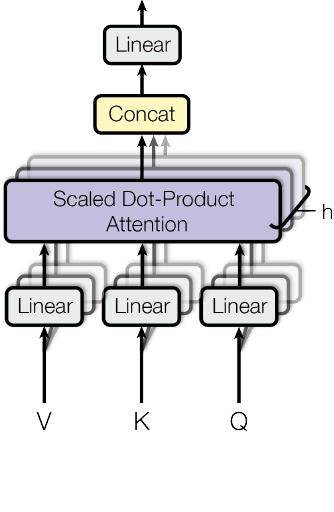

In [67]:
plt_img_base64(docs[0])


In [63]:
context = chain_multimodal_context.invoke(query)[0].content


[{'type': 'text',
  'text': "You are an AI assistant with expertise in deep learning research papers.\nYou will be given information that may include text, tables, and charts related to business performance and industry trends.\nYour task is to analyze this information and provide a clear, concise answer to the user's question.\nFocus on the most relevant data points and insights that directly address the user's query.\nUser's question: explain the attention mechanism?\n\nInformation provided:\n11\n\n[25] Mitchell P Marcus, Mary Ann Marcinkiewicz, and Beatrice Santorini. Building a large annotated corpus of english: The penn treebank. Computational linguistics, 19(2):313–330, 1993.\n\n[26] David McClosky, Eugene Charniak, and Mark Johnson. Effective self-training for parsing. In Proceedings of the Human Language Technology Conference of the NAACL, Main Conference, pages 152–159. ACL, June 2006.\n\n[27] Ankur Parikh, Oscar Täckström, Dipanjan Das, and Jakob Uszkoreit. A decomposable att
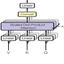

In [64]:
context

[Document(id='94bbcf95-8ee8-43ca-9010-76f30b4893e8', metadata={'doc_id': 'd47b4231-7636-4db9-bee4-8cca526fe8a2'}, page_content='The image depicts a complex neural network architecture, likely a Transformer model, with two main sections: the left side representing the encoder and the right side representing the decoder.\n\n**Key Components:**\n\n* **Encoder (Left Side):**\n\t+ Takes in "Inputs" and passes them through an "Input Embedding" layer.\n\t+ The embedded inputs are then added with "Positional Encoding" and fed into a stack of identical layers (Nx), each consisting of:\n\t\t- "Multi-Head Attention" with "Add & Norm".\n\t\t- "Feed Forward" with "Add & Norm".\n* **Decoder (Right Side):**\n\t+ Takes in "Outputs (shifted right)" and passes them through an "Output Embedding" layer.\n\t+ The embedded outputs are then added with "Positional Encoding" and fed into a stack of identical layers (Nx), each consisting of:\n\t\t- "Masked Multi-Head Attention" with "Add & Norm".\n\t\t- "Multi-

In [70]:
message = HumanMessage(
        content=context
    )

# Send the chat request
response = llm_client.invoke([message])
print(response.content)

The attention mechanism! A fundamental component in many deep learning models, particularly in natural language processing (NLP).

The attention mechanism is a technique used in neural networks to focus on specific parts of the input data that are relevant for a particular task. In the context of NLP, it allows models to weigh the importance of different input elements, such as words or tokens, when generating output.

The provided references don't directly explain the attention mechanism, but [27] mentions a "decomposable attention model." Let's break it down:

**What is attention?**

Attention is a way for a model to selectively concentrate on certain parts of the input data, rather than using the entire input equally. This is inspired by the way humans focus their attention on specific parts of the environment when performing tasks.

**How does attention work?**

The attention mechanism typically consists of three main components:

1. **Query**: This represents the context or the ta